# Notebook Overview
This Test file attempts to implment a different model architecture to improve models accuracy it  uses to convolution layers and 2 dense networks

# Conclusion

Achieved an accuracy of 62% on test data and 68.20% on validation

In [8]:
try:
  # This command only in Colab.
  %tensorflow_version 2
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Get project files from internet
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip #extracts file

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
#counts no of files in each drectory
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.864.jpg  
  inflating: cats_and_dogs/train/dogs/dog.870.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.870.jpg  
  inflating: cats_and_dogs/train/dogs/dog.871.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.871.jpg  
  inflating: cats_and_dogs/train/dogs/dog.865.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.865.jpg  
  inflating: cats_and_dogs/train/dogs/dog.695.jpg  
  inflating: __MACOSX/cats_and

In [3]:
print(total_train,total_test,total_val)

2001 51 1001


In [4]:
# 3
train_image_generator = ImageDataGenerator(rescale = 1./ 255) #ensures float division is applied
validation_image_generator =  ImageDataGenerator(rescale = 1./ 255)
test_image_generator =  ImageDataGenerator(rescale = 1./ 255)

train_data_gen = train_image_generator.flow_from_directory(train_dir,batch_size = batch_size,target_size = (IMG_HEIGHT,IMG_WIDTH), class_mode = 'binary')
val_data_gen = validation_image_generator.flow_from_directory(validation_dir,batch_size = batch_size,target_size = (IMG_HEIGHT,IMG_WIDTH), class_mode = 'binary')
'''
flow from directory expects nested directories since test folder lacks one the appropriate decision is to point back to the parent then direct it to test
classes_mode = None, test images have no labels
'''
parent_dir = PATH

test_data_gen = test_image_generator.flow_from_directory(parent_dir,classes = ['test'],target_size = (IMG_HEIGHT,IMG_WIDTH),batch_size = batch_size,shuffle = False,class_mode=None)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 50 images belonging to 1 classes.


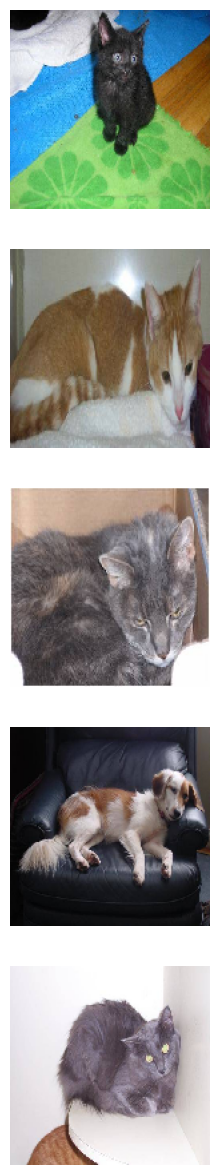

In [5]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [6]:
# 5
train_image_generator = ImageDataGenerator( rescale = 1./255,
rotation_range=15, # images will be randomly rotated by a degree of 15
width_shift_range=0.2,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.1,#img randomly shifted vertically
shear_range=0.1,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.2, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')





Found 2000 images belonging to 2 classes.


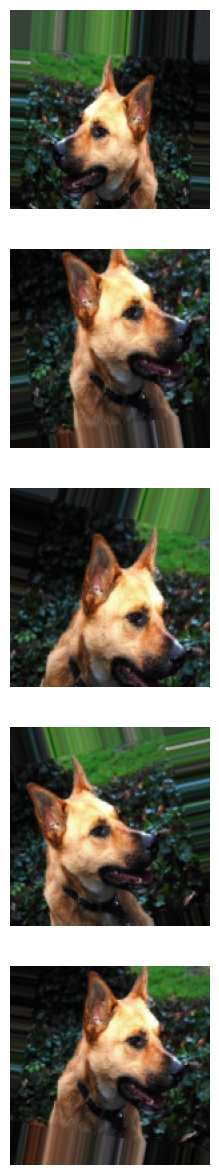

In [11]:
# 6
#applying data augmentation
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [13]:
# 7
#building model architecture
model = Sequential()
model.add(Input(shape = (IMG_HEIGHT,IMG_WIDTH,3))) #input shape

#first convolution layer
model.add(Conv2D((32),(5,5),activation = 'relu'))
model.add(MaxPooling2D((2,2))) #enhances feautures,reduces dimensionality

#second convolution layer
model.add(Conv2D((64),(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2))) #enhances feautures,reduces dimensionality

#Flatten Layer
model.add(Flatten())

#Predition Dense Layer

model.add(Dense(128, activation= 'relu'))
model.add(Dense(1, activation = 'sigmoid')) # 1 neuron as its binary



#model compiling

model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])






model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 146, 146, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 78400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,035,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,056,385 (38.36 MB)

 Trainable params: 10,056,385 (38.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#training model
history = model.fit(train_data_gen,
                    steps_per_epoch= int(np.ceil(total_train / batch_size)), #should correspond directly to the total images divided by batch size
                    epochs = 20,
                    validation_data=val_data_gen,
                    validation_steps=int(np.ceil(total_val / batch_size)))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - accuracy: 0.5075 - loss: 0.7422 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.5125 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - accuracy: 0.5035 - loss: 0.6942 - val_accuracy: 0.5760 - val_loss: 0.6900
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 145s 6s/step - accuracy: 0.5065 - loss: 0.6924 - val_accuracy: 0.5220 - val_loss: 0.6894
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 149s 7s/step - accuracy: 0.5670 - loss: 0.6886 - val_accuracy: 0.5640 - val_loss: 0.6838
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.5650 - loss: 0.6872 - val_accuracy: 0.5870 - val_loss: 0.6787
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 145s 6s/step - accuracy: 0.5800 - loss: 0.6822 - val_accuracy: 0.5780 - val_loss: 0.6742
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 99s 6s/step - accuracy: 0.5440 - loss: 0.6855 - val_accuracy: 0.5740 - va

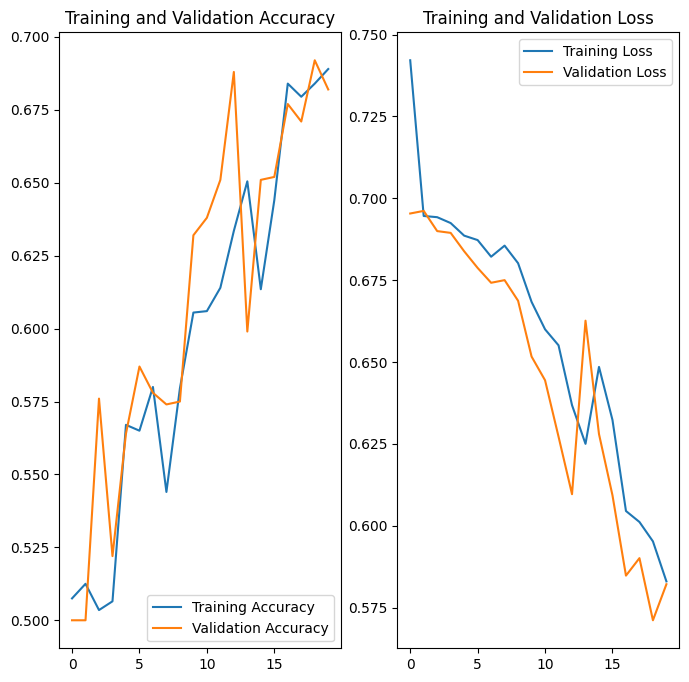

In [19]:
# 9
# visualize accuracy and models loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [22]:
#generate list of probabilities
probabilities = model.predict(test_data_gen, steps = int(np.ceil(total_test / batch_size)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step


In [23]:
# 11
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0

for probability, answer in zip(probabilities, answers):
  if round(probability[0]) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

Your model correctly identified 62.0% of the images of cats and dogs.
You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!
